{'port': '/dev/ttyUSB0', 'baudrate': 230400, 'duration_seconds': 3.0, 'descriptor_hex': 'a55a0500004081', 'total_packets': 378, 'valid_packets': 341, 'point_count': 7078}


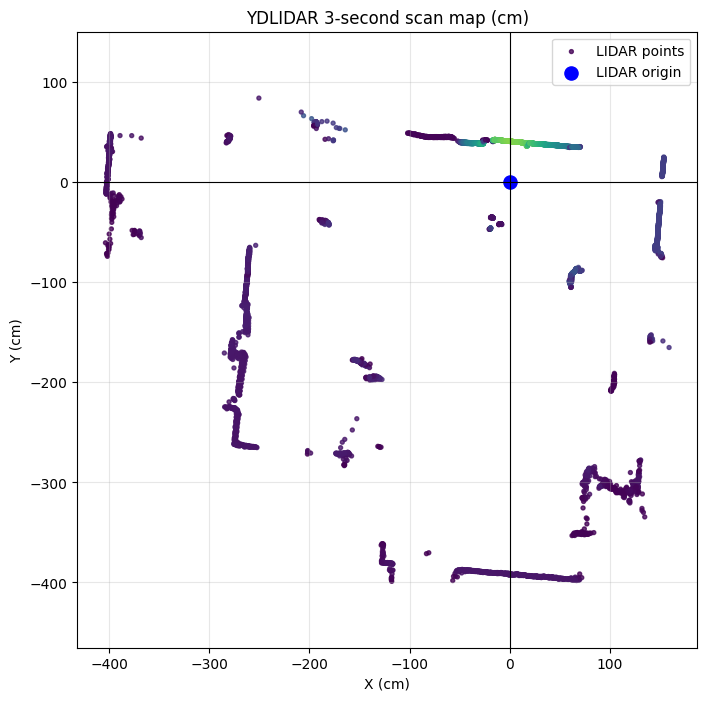

In [5]:
import math
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import serial
from PIL import Image

START_SCAN_COMMAND = b"\xA5\x60"
STOP_SCAN_COMMAND = b"\xA5\x65"
PACKET_HEADER = b"\xAA\x55"
DEFAULT_BAUDRATE = 230400
SCAN_DURATION_SECONDS = 3.0

def detect_default_port():
    by_id_dir = Path("/dev/serial/by-id")
    if by_id_dir.exists():
        for candidate in sorted(by_id_dir.iterdir()):
            name = candidate.name.lower()
            if any(t in name for t in ("ydlidar", "cp210", "silicon", "uart")):
                return str(candidate.resolve())
    for pattern in ("ttyUSB*", "ttyACM*"):
        matches = sorted(Path("/dev").glob(pattern))
        if matches:
            return str(matches[0])
    return "/dev/ttyUSB0"

def checksum_is_valid(packet):
    if len(packet) < 10:
        return False
    n = packet[3]
    if len(packet) != 10 + (3 * n):
        return False
    checksum = packet[8] | (packet[9] << 8)
    running = (packet[0] | (packet[1] << 8)) ^ (packet[2] | (packet[3] << 8))
    running ^= packet[4] | (packet[5] << 8)
    running ^= packet[6] | (packet[7] << 8)
    for i in range(n):
        o = 10 + (3 * i)
        running ^= packet[o]
        running ^= packet[o + 1] | (packet[o + 2] << 8)
    return running == checksum

def first_level_angle(lsb, msb):
    return ((lsb | (msb << 8)) >> 1) / 64.0

def diff_angle(end_angle, start_angle):
    if end_angle < start_angle:
        end_angle += 360.0
    return end_angle - start_angle

def corrected_angle(angle_deg, distance_mm):
    if distance_mm == 0:
        return 0.0
    angle = angle_deg + math.degrees(math.atan2(21.8 * (155.3 - distance_mm), 155.3 * distance_mm))
    if angle < 0.0:
        angle += 360.0
    return angle

def extract_packets(buffer):
    packets = []
    while True:
        idx = buffer.find(PACKET_HEADER)
        if idx < 0:
            return packets, bytearray(buffer[-1:])
        if idx > 0:
            del buffer[:idx]
        if len(buffer) < 10:
            return packets, buffer
        n = buffer[3]
        packet_len = 10 + (3 * n)
        if len(buffer) < packet_len:
            return packets, buffer
        packets.append(bytes(buffer[:packet_len]))
        del buffer[:packet_len]

def parse_packet_to_points_cm(packet):
    if not checksum_is_valid(packet):
        return []
    n = packet[3]
    start_angle = first_level_angle(packet[4], packet[5])
    end_angle = first_level_angle(packet[6], packet[7])
    delta = diff_angle(end_angle, start_angle)
    points = []
    for i in range(n):
        o = 10 + (3 * i)
        intensity = packet[o] + ((packet[o + 1] & 0b11) << 8)
        distance_mm = (packet[o + 1] >> 2) | (packet[o + 2] << 6)
        if distance_mm <= 0:
            continue
        if n <= 1:
            base_angle = start_angle
        elif i == 0:
            base_angle = start_angle
        elif i == n - 1:
            base_angle = end_angle
        else:
            base_angle = (delta / (n - 1)) * i + start_angle
            if base_angle >= 360.0:
                base_angle -= 360.0
        angle = corrected_angle(base_angle, distance_mm)
        x_cm = (distance_mm * math.cos(math.radians(angle))) / 10.0
        y_cm = -(distance_mm * math.sin(math.radians(angle))) / 10.0
        points.append((x_cm, y_cm, intensity))
    return points

def capture_scan_points_cm(port, baudrate=DEFAULT_BAUDRATE, duration_seconds=3.0):
    all_points = []
    total_packets = 0
    valid_packets = 0
    buffer = bytearray()
    with serial.Serial(port=port, baudrate=baudrate, timeout=0.2) as lidar_serial:
        lidar_serial.reset_input_buffer()
        lidar_serial.reset_output_buffer()
        lidar_serial.write(START_SCAN_COMMAND)
        lidar_serial.flush()
        descriptor = lidar_serial.read(7)
        started_at = time.monotonic()
        deadline = started_at + duration_seconds
        try:
            while time.monotonic() < deadline:
                chunk = lidar_serial.read(4096)
                if not chunk:
                    continue
                buffer.extend(chunk)
                packets, buffer = extract_packets(buffer)
                for packet in packets:
                    total_packets += 1
                    pts = parse_packet_to_points_cm(packet)
                    if pts:
                        valid_packets += 1
                        all_points.extend(pts)
        finally:
            lidar_serial.write(STOP_SCAN_COMMAND)
            lidar_serial.flush()

    if all_points:
        arr = np.array(all_points, dtype=float)
        points_cm = arr[:, :2]
        intensity = arr[:, 2]
    else:
        points_cm = np.empty((0, 2), dtype=float)
        intensity = np.empty((0,), dtype=float)

    meta = {
        "port": port,
        "baudrate": baudrate,
        "duration_seconds": duration_seconds,
        "descriptor_hex": descriptor.hex(),
        "total_packets": total_packets,
        "valid_packets": valid_packets,
        "point_count": int(points_cm.shape[0]),
    }
    return points_cm, intensity, meta

def plot_map(points_cm, intensity, title):
    fig, ax = plt.subplots(figsize=(8, 8))
    if points_cm.size > 0:
        ax.scatter(points_cm[:, 0], points_cm[:, 1], c=intensity, s=8, cmap="viridis", alpha=0.8, label="LIDAR points")
    ax.scatter([0.0], [0.0], c="blue", s=90, label="LIDAR origin")
    ax.axhline(0.0, color="black", linewidth=0.8)
    ax.axvline(0.0, color="black", linewidth=0.8)
    ax.set_xlabel("X (cm)")
    ax.set_ylabel("Y (cm)")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.axis("equal")
    ax.legend(loc="upper right")
    plt.show()

port = detect_default_port()
scan_points_cm, scan_intensity, scan_meta = capture_scan_points_cm(port=port, duration_seconds=SCAN_DURATION_SECONDS)
print(scan_meta)
plot_map(scan_points_cm, scan_intensity, "YDLIDAR 3-second scan map (cm)")

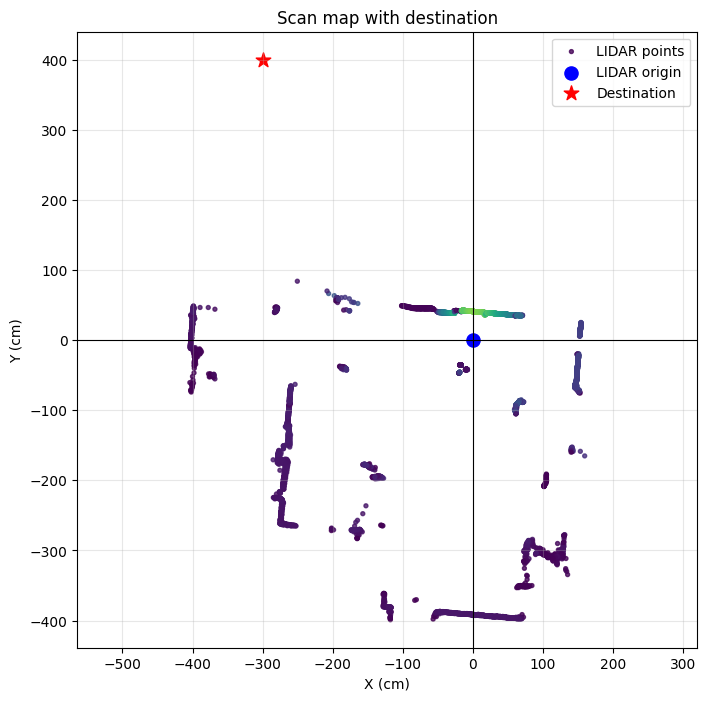

destination = (-300.0, 400.0) cm


In [6]:
# Set destination in centimeters and run this cell.
destination = (-300.0, 400.0)

if "scan_points_cm" not in globals():
    raise RuntimeError("Run Cell 1 first to capture LIDAR points.")
if not isinstance(destination, (tuple, list)) or len(destination) != 2:
    raise ValueError("destination must be (x_cm, y_cm).")

destination = (float(destination[0]), float(destination[1]))

fig, ax = plt.subplots(figsize=(8, 8))
if scan_points_cm.size > 0:
    ax.scatter(scan_points_cm[:, 0], scan_points_cm[:, 1], c=scan_intensity, s=8, cmap="viridis", alpha=0.8, label="LIDAR points")
ax.scatter([0.0], [0.0], c="blue", s=90, label="LIDAR origin")
ax.scatter([destination[0]], [destination[1]], c="red", s=120, marker="*", label="Destination")
ax.axhline(0.0, color="black", linewidth=0.8)
ax.axvline(0.0, color="black", linewidth=0.8)
ax.set_xlabel("X (cm)")
ax.set_ylabel("Y (cm)")
ax.set_title("Scan map with destination")
ax.grid(True, alpha=0.3)
ax.axis("equal")
ax.legend(loc="upper right")
plt.show()

print(f"destination = {destination} cm")

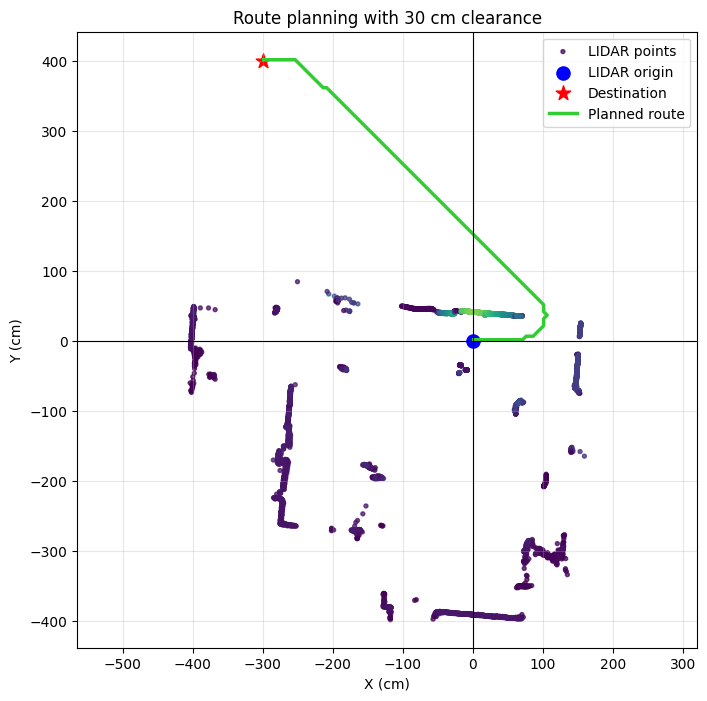

Route points: 107
Approx route length: 687.4 cm


In [7]:
import heapq
from collections import deque

MIN_CLEARANCE_CM = 30.0
GRID_RESOLUTION_CM = 5.0

def world_to_grid(x_cm, y_cm, min_x, min_y, resolution_cm):
    gx = int(round((x_cm - min_x) / resolution_cm))
    gy = int(round((y_cm - min_y) / resolution_cm))
    return gx, gy

def grid_to_world(gx, gy, min_x, min_y, resolution_cm):
    return min_x + gx * resolution_cm, min_y + gy * resolution_cm

def in_bounds(gx, gy, nx, ny):
    return 0 <= gx < nx and 0 <= gy < ny

def nearest_free_cell(start_cell, occupancy):
    nx = occupancy.shape[1]
    ny = occupancy.shape[0]
    sx, sy = start_cell
    if in_bounds(sx, sy, nx, ny) and not occupancy[sy, sx]:
        return start_cell
    q = deque([start_cell])
    visited = {start_cell}
    directions = [(1, 0), (-1, 0), (0, 1), (0, -1), (1, 1), (1, -1), (-1, 1), (-1, -1)]
    while q:
        cx, cy = q.popleft()
        for dx, dy in directions:
            nx_cell, ny_cell = cx + dx, cy + dy
            ncell = (nx_cell, ny_cell)
            if ncell in visited or not in_bounds(nx_cell, ny_cell, nx, ny):
                continue
            if not occupancy[ny_cell, nx_cell]:
                return ncell
            visited.add(ncell)
            q.append(ncell)
    return None

def astar(start_cell, goal_cell, occupancy):
    nx = occupancy.shape[1]
    ny = occupancy.shape[0]
    neighbors = [(1, 0, 1.0), (-1, 0, 1.0), (0, 1, 1.0), (0, -1, 1.0), (1, 1, 2**0.5), (1, -1, 2**0.5), (-1, 1, 2**0.5), (-1, -1, 2**0.5)]
    def h(a, b):
        return ((a[0] - b[0]) ** 2 + (a[1] - b[1]) ** 2) ** 0.5
    open_heap = []
    heapq.heappush(open_heap, (0.0, start_cell))
    came_from = {}
    g_score = {start_cell: 0.0}
    while open_heap:
        _, current = heapq.heappop(open_heap)
        if current == goal_cell:
            path = [current]
            while current in came_from:
                current = came_from[current]
                path.append(current)
            path.reverse()
            return path
        for dx, dy, move_cost in neighbors:
            nx_cell = current[0] + dx
            ny_cell = current[1] + dy
            if not in_bounds(nx_cell, ny_cell, nx, ny) or occupancy[ny_cell, nx_cell]:
                continue
            neighbor = (nx_cell, ny_cell)
            tentative_g = g_score[current] + move_cost
            if tentative_g < g_score.get(neighbor, float("inf")):
                came_from[neighbor] = current
                g_score[neighbor] = tentative_g
                heapq.heappush(open_heap, (tentative_g + h(neighbor, goal_cell), neighbor))
    return None

if "scan_points_cm" not in globals():
    raise RuntimeError("Run Cell 1 first.")
if "destination" not in globals():
    raise RuntimeError("Run Cell 2 first.")
if scan_points_cm.size == 0:
    raise RuntimeError("No scan points found. Re-run Cell 1.")

start_world = (0.0, 0.0)
goal_world = (float(destination[0]), float(destination[1]))
all_x = np.concatenate([scan_points_cm[:, 0], np.array([start_world[0], goal_world[0]])])
all_y = np.concatenate([scan_points_cm[:, 1], np.array([start_world[1], goal_world[1]])])
margin = MIN_CLEARANCE_CM + 40.0
min_x = float(np.min(all_x) - margin)
max_x = float(np.max(all_x) + margin)
min_y = float(np.min(all_y) - margin)
max_y = float(np.max(all_y) + margin)

nx = int(np.ceil((max_x - min_x) / GRID_RESOLUTION_CM)) + 1
ny = int(np.ceil((max_y - min_y) / GRID_RESOLUTION_CM)) + 1
occupancy = np.zeros((ny, nx), dtype=bool)

radius_cells = int(np.ceil(MIN_CLEARANCE_CM / GRID_RESOLUTION_CM))
offsets = []
for dx in range(-radius_cells, radius_cells + 1):
    for dy in range(-radius_cells, radius_cells + 1):
        if (dx * dx + dy * dy) <= (radius_cells * radius_cells):
            offsets.append((dx, dy))

obs_ix = np.round((scan_points_cm[:, 0] - min_x) / GRID_RESOLUTION_CM).astype(int)
obs_iy = np.round((scan_points_cm[:, 1] - min_y) / GRID_RESOLUTION_CM).astype(int)
for ox, oy in set(zip(obs_ix.tolist(), obs_iy.tolist())):
    for dx, dy in offsets:
        cx = ox + dx
        cy = oy + dy
        if 0 <= cx < nx and 0 <= cy < ny:
            occupancy[cy, cx] = True

start_cell = world_to_grid(start_world[0], start_world[1], min_x, min_y, GRID_RESOLUTION_CM)
goal_cell = world_to_grid(goal_world[0], goal_world[1], min_x, min_y, GRID_RESOLUTION_CM)
start_cell = nearest_free_cell(start_cell, occupancy)
goal_cell = nearest_free_cell(goal_cell, occupancy)
if start_cell is None or goal_cell is None:
    raise RuntimeError("Could not place start/goal on free space with 30 cm clearance.")

path_cells = astar(start_cell, goal_cell, occupancy)
if path_cells is None:
    raise RuntimeError("No collision-free route found with 30 cm clearance.")

route_cm = np.array([grid_to_world(px, py, min_x, min_y, GRID_RESOLUTION_CM) for (px, py) in path_cells], dtype=float)

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(scan_points_cm[:, 0], scan_points_cm[:, 1], c=scan_intensity, s=8, cmap="viridis", alpha=0.75, label="LIDAR points")
ax.scatter([0.0], [0.0], c="blue", s=90, label="LIDAR origin")
ax.scatter([goal_world[0]], [goal_world[1]], c="red", s=120, marker="*", label="Destination")
ax.plot(route_cm[:, 0], route_cm[:, 1], color="limegreen", linewidth=2.5, label="Planned route")
ax.axhline(0.0, color="black", linewidth=0.8)
ax.axvline(0.0, color="black", linewidth=0.8)
ax.set_xlabel("X (cm)")
ax.set_ylabel("Y (cm)")
ax.set_title("Route planning with 30 cm clearance")
ax.grid(True, alpha=0.3)
ax.axis("equal")
ax.legend(loc="upper right")
plt.show()

route_length_cm = float(np.sum(np.linalg.norm(np.diff(route_cm, axis=0), axis=1)))
print(f"Route points: {len(route_cm)}")
print(f"Approx route length: {route_length_cm:.1f} cm")